<a href="https://colab.research.google.com/github/riggij-sys/Jake-Riggi-Repository/blob/main/coding_homework_4_ipynb_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Jake Riggi
*Neur 265*

**March 3rd**

In [42]:
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats

In [43]:
url='https://raw.githubusercontent.com/hallockh/neur_265_spring2026/refs/heads/main/data/patch_seq_expanded.csv'
patch_seq=pd.read_csv(url)
patch_seq
#This code cell loaded our pandas array from our raw csv file

,ISI,Fast_Trough,Marker
0,77.337143,-49.899998,Sst
1,17.177895,-44.462498,Sst
2,48.294737,-47.350002,Sst
3,8.980000,-45.656254,Sst
4,30.315385,-50.737499,Sst
...,...,...,...
360,11.052333,-54.743752,Pvalb
361,8.860360,-64.875008,Pvalb
362,9.192897,-51.312504,Pvalb
363,10.544731,-52.281254,Pvalb


<Axes: xlabel='Marker', ylabel='count'>

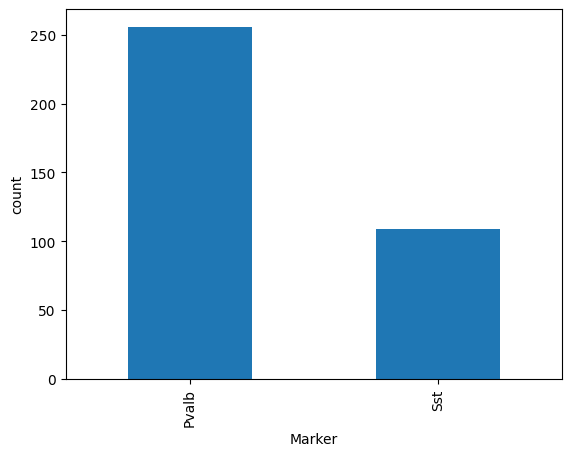

In [44]:
marker_counts=patch_seq['Marker'].value_counts()
marker_counts.plot(kind='bar', ylabel='count')
#made a bar graph showing how many times each type of internueron shows up in our dataframe

<Axes: ylabel='count'>

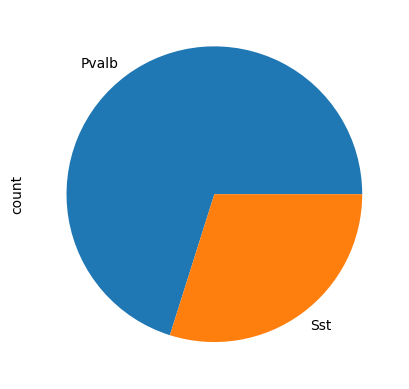

In [45]:
marker_counts=patch_seq['Marker'].value_counts()
marker_counts.plot(kind='pie', ylabel='count')
#this code just visualizes our value ccounts for each type of interneuron in a slightly different way compared to the cell above


Text(0, 0.5, 'fast_trough')

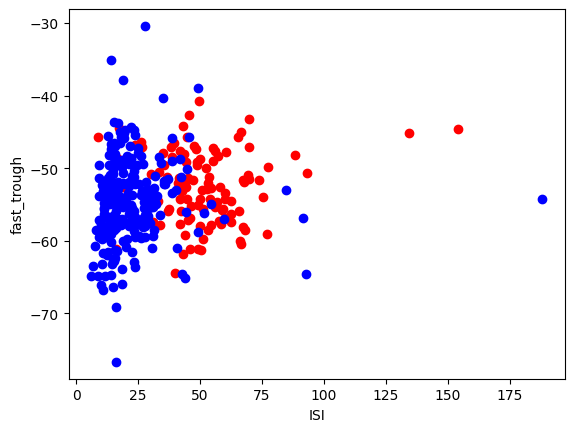

In [46]:
patch_length = len(patch_seq)

for i in range(patch_length):
  if patch_seq.iloc[i,2] == 'Sst':
    plt.scatter(patch_seq.iloc[i,0],patch_seq.iloc[i,1],color = "red")
  else:
    plt.scatter(patch_seq.iloc[i,0],patch_seq.iloc[i,1],color = "blue")

plt.xlabel('ISI')
plt.ylabel('fast_trough')

#this code uses a for loop to take values from our patch_seq dataframme and place them on a scatterplot comparing their ISI to their fast-trough. Sst neurons are labled red and pvalb neurons are labled blue


In [47]:
def patchScatter():
  """
  This function outputs the scatterplot in the step above
  """
  for i in range(patch_length):
    if patch_seq.iloc[i,2] == 'Sst':
      plt.scatter(patch_seq.iloc[i,0],patch_seq.iloc[i,1],color = "red")
    else:
      plt.scatter(patch_seq.iloc[i,0],patch_seq.iloc[i,1],color = "blue")

  plt.xlabel('ISI')
  plt.ylabel('fast_trough')
  #this code cell turns the code from the cell above into a function call patchscatter

In [48]:
patch_seq.groupby('Marker')['Fast_Trough'].describe()
#this code cell describes specific statistics about each set of data based on each marker genes fast-trough data.

,count,mean,std,min,25%,50%,75%,max
Marker,,,,,,,,
Pvalb,256.0,-54.548074,5.870670,-76.687508,-57.914063,-54.490629,-51.364065,-30.406252
Sst,109.0,-52.514968,4.958103,-64.375008,-55.931252,-52.568752,-48.500000,-40.781254


It looks like Pvalb neurons have a lower mean, thus likely have a more negative undershoot following an action potential.

In [49]:
patch_seq.groupby('Marker')['Fast_Trough'].skew()
#this code cell returns the skewness of the fast-trough for each of our types of interneurons

,Fast_Trough
Marker,
Pvalb,0.19536
Sst,0.00125


Both of these data sets can be considered normally distributed as the value rturned by the skewness test for both of these interneurons is between .5 and -.5

In [50]:
patch_seq.groupby('Marker')['ISI'].skew()
#this code cell returns the skewness test for the ISI of each type of interneuron

,ISI
Marker,
Pvalb,5.596386
Sst,1.857850


Our data seems rather highly skewed for both our Pvalb and Sst interneurons as our skewness test shows a value of greater than .5 for both of these interneurons

In [51]:
sst_neurons = patch_seq[patch_seq['Marker']=='Sst']
pvalb_neurons=patch_seq[patch_seq['Marker']=='Pvalb']

#thi cell defines 2 new variables that contain just data for a specific type of inteneuron

In [52]:
stats.ttest_ind(sst_neurons['Fast_Trough'],pvalb_neurons['Fast_Trough'])
#this cell runs an ndependent samples ttest between the fast-trough data betwen these two interneurons

TtestResult(statistic=np.float64(3.1660773376899147), pvalue=np.float64(0.0016757984214133585), df=np.float64(363.0))

Our pvalue is .0017, which is less than our statistically siignifgant value of .05 indicating that there is a statistically signifigant difference in the undershoot voltage in each type of interneuron

In [55]:
sst=sst_neurons['ISI'].dropna()
pvalb=pvalb_neurons['ISI'].dropna()

stats.ttest_ind(sst,pvalb)
#this code cell creates 2 new variables that drop our missing values in the ISI column in our dataframe and then uses those two new variables to run an independent samples ttest

TtestResult(statistic=np.float64(14.643966775010774), pvalue=np.float64(2.694292788633572e-38), df=np.float64(354.0))

in this case, our pvalue is 2.694, which is not enough to safely indicate that the difference between the ISI of pvalb neurons and sst neurons is a statistially signifigant dfference. Thus our ISI does not signfigantly differ between our two groups